 Lab-17: Find similar Bollywood / Hollywood movie descriptions using word embeddings


In [1]:
import sys
!{sys.executable} -m pip install gensim
!wget --no-check-certificate https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.8 MB/s eta 0:00:00
--2026-06-17 16:59:39--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-17 16:59:39--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  5.01MB/s    in 2m 38s  

2026-06-17 17:02:18 (5.19 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]



In [2]:
from gensim.scripts.glove2word2vec import glove2word2vec
glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.w2v.txt')


/tmp/ipykernel_8748/2920286412.py:2: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.w2v.txt')


(400000, 100)

In [3]:
import numpy as np
import pandas as pd
from gensim.models import KeyedVectors
glove = KeyedVectors.load_word2vec_format('glove.6B.100d.w2v.txt',
binary=False)
movies = [
{'title':'Dilwale Dulhania Le Jayenge',
'desc':'A young man follows the woman he loves to India after they fall inlove in Europe'},
{'title':'Lagaan',
'desc':'Villagers challenge British colonisers to a cricket match to avoipaying heavy taxes'},
{'title':'Dangal',
'desc':'A father trains his daughters to become world class wrestlers against all odds'},
{'title':'3 Idiots',
'desc':'Three college friends question the pressure of engineering education in India'},
{'title':'Dil Chahta Hai',
'desc':'Three best friends navigate love relationships and life aftergraduation'},
{'title':'Titanic',
'desc':'A wealthy girl and a poor artist fall in love on a doomed oceanliner'},
{'title':'Rocky',
'desc':'An underdog boxer trains relentlessly for a shot at the worldeavyweight champion'},
{'title':'Good Will Hunting',
'desc':'A genius janitor from Boston works through emotional trauma with aherapist'},
{'title':'Chariots of Fire',
'desc':'Two British athletes train and compete for glory in the 1924lympic Games'},
{'title':'Before Sunrise',
'desc':'Two strangers meet on a train in Europe and spend one romanticight in Vienna'},
]
df = pd.DataFrame(movies)
print(df[['title']].to_string())

                         title
0  Dilwale Dulhania Le Jayenge
1                       Lagaan
2                       Dangal
3                     3 Idiots
4               Dil Chahta Hai
5                      Titanic
6                        Rocky
7            Good Will Hunting
8             Chariots of Fire
9               Before Sunrise


In [4]:
from sklearn.metrics.pairwise import cosine_similarity
def sentence_vector(text, model, dim=100):
  tokens = text.lower().split()
  vecs = [model[t] for t in tokens if t in model]
  return np.mean(vecs, axis=0) if vecs else np.zeros(dim)
df['vector'] = df['desc'].apply(lambda d: sentence_vector(d, glove))
V = np.stack(df['vector'].values)
def find_similar(query_desc, df, top_n=3):
  qvec = sentence_vector(query_desc, glove).reshape(1, -1)
  sims = cosine_similarity(qvec, V)[0]
  idx = np.argsort(sims)[::-1][:top_n]
  result = df.iloc[idx][['title']].copy()
  result['similarity'] = np.round(sims[idx], 3)
  return result
q1 = 'An underdog athlete trains hard and wins against all expectations'
print('QUERY:', q1)
print(find_similar(q1, df).to_string(index=False))

q2 = 'Two people fall in love while travelling across Europe'
print('\nQUERY:', q2)
print(find_similar(q2, df).to_string(index=False))


QUERY: An underdog athlete trains hard and wins against all expectations
           title  similarity
           Rocky       0.928
Chariots of Fire       0.928
          Dangal       0.926

QUERY: Two people fall in love while travelling across Europe
                      title  similarity
             Before Sunrise       0.957
Dilwale Dulhania Le Jayenge       0.935
           Chariots of Fire       0.913


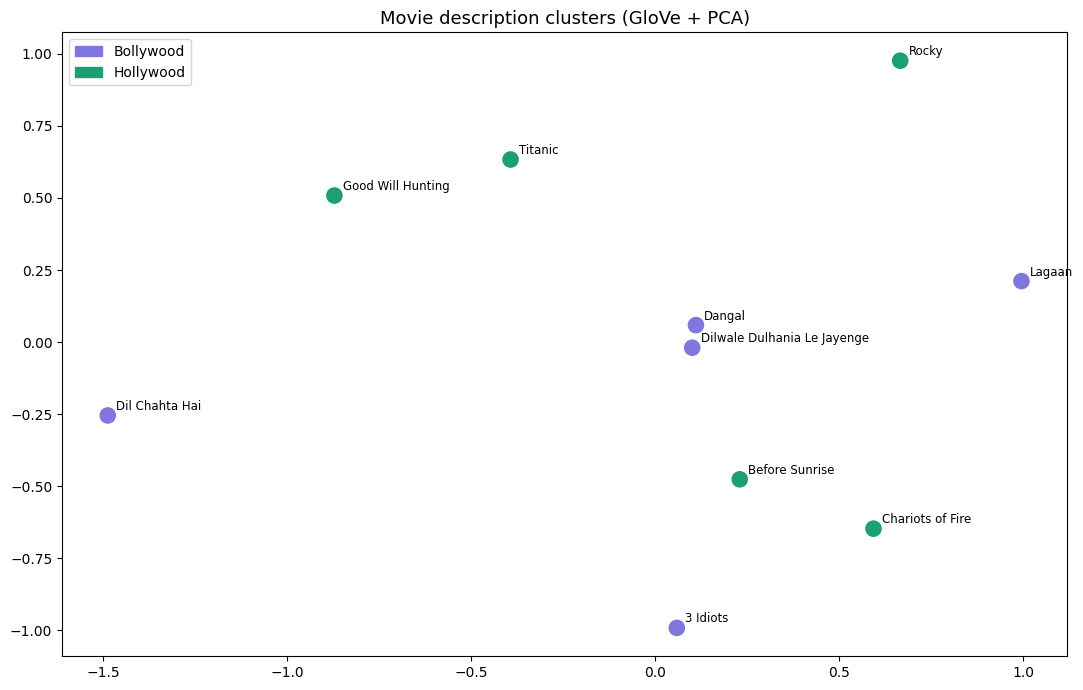

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(V)
colours = ['#7F77DD']*5 + ['#1D9E75']*5
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(coords[:,0], coords[:,1], c=colours, s=120, zorder=3)
for i, row in df.iterrows():
    ax.annotate(row['title'], coords[i], fontsize=8.5,
               xytext=(6, 4), textcoords='offset points')
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='#7F77DD', label='Bollywood'),
    mpatches.Patch(color='#1D9E75', label='Hollywood'),
], fontsize=10)
ax.set_title('Movie description clusters (GloVe + PCA)', fontsize=13)
plt.tight_layout()
plt.savefig('movie_clusters.png', dpi=150)
plt.show()